# #1

기사 본문을 불러왔습니다.

--- 1. 문장/단어 토큰화 ---
단어 토큰화 완료 (일부 출력): ['스타', '십', '발사', '전야', '[', 'AP', '=', '연합뉴스', '.', '재판매'] ...
--- 2. 품사 부착 ---
--- 3. 개체명 인식 ---
--- 4. 원형 복원 및 5. 불용어 처리 ---
전처리 완료 (일부 출력): ['스타', '발사', '전야', '연합뉴스', '재판매', '금지', '서울', '연합뉴스', '정주', '스페이스'] ...
--- 6. 시각화 (가장 많이 등장한 단어 Top 10) ---


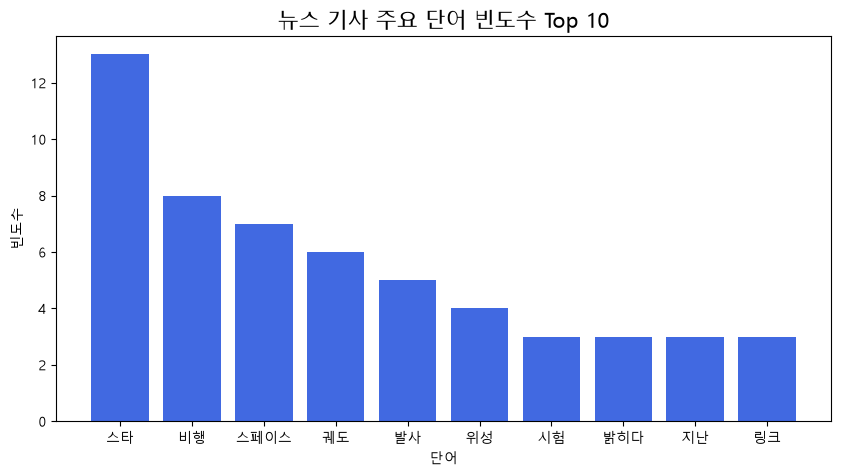

In [6]:
import os
os.environ['JAVA_HOME'] = r'C:\Program Files\Java\jdk-17'

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from konlpy.tag import Okt

# 1. 형태소 분석기 객체 생성
okt = Okt() 

# 2. 네이버 뉴스 기사 본문 자동 수집
url = "https://n.news.naver.com/mnews/article/001/0016341081"

# 일반 브라우저인 것처럼 속이는 User-Agent 헤더
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# 네이버 뉴스 본문 영역 추출
article_body = soup.find(id='dic_area')
if article_body:
    text = article_body.get_text(strip=True)
    print("기사 본문을 불러왔습니다.\n")
else:
    text = "기사 본문을 불러오지 못했습니다. URL을 확인해주세요."
    print(text)

# 3. 자연어 전처리 진행
print("--- 1. 문장/단어 토큰화 ---")
sentences = [s.strip() for s in text.split('.') if s.strip()]
words = okt.morphs(text)
print("단어 토큰화 완료 (일부 출력):", words[:10], "...")

print("--- 2. 품사 부착 ---")
pos_tags = okt.pos(text)

print("--- 3. 개체명 인식 ---")
entities = [word for word, pos in pos_tags if pos == 'Noun']

print("--- 4. 원형 복원 및 5. 불용어 처리 ---")
pos_tags_stemmed = okt.pos(text, stem=True)

# 불용어 리스트 구성
stop_words = ['연', '점', '것', '수', '이', '은', '는', '과', '를', '로', '하다', '있다', '되다', '이다', '없다', '않다', '에서', '기자', '부터', '까지'] 

cleaned_words = []
for word, pos in pos_tags_stemmed:
    if pos in ['Noun', 'Verb', 'Adjective']: 
        if word not in stop_words and len(word) >= 2:
            cleaned_words.append(word)

print("전처리 완료 (일부 출력):", cleaned_words[:10], "...")

# 4. 시각화
print("--- 6. 시각화 (가장 많이 등장한 단어 Top 10) ---")
word_counts = Counter(cleaned_words)
top_words = word_counts.most_common(10)

words_labels, counts = zip(*top_words)

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 5))
plt.bar(range(len(words_labels)), counts, color='royalblue')

plt.title('뉴스 기사 주요 단어 빈도수 Top 10', size=15)
plt.xlabel('단어')
plt.ylabel('빈도수')
plt.xticks(range(len(words_labels)), words_labels) 

plt.show()

**1. 토큰화 과정에서 발생한 문제점과 해결 방안 및 보완책 제안**

이번 실습 과정에서 '금융통화위원회', '기준금리'와 같은 복합명사나 새로운 고유명사가 하나의 의미 있는 단어로 인식되지 않고 '금융', '통화', '위원회' 등으로 지나치게 잘게 쪼개지는 현상을 확인했습니다. 이렇게 단어가 과도하게 분리되면 문서의 진짜 핵심 주제를 파악하기 어려워집니다. 이를 해결하기 위해 형태소 분석기 내부에 '사용자 추가 사전'을 등록하여 특정 단어가 분리되지 않도록 설정하는 방법을 찾아보았습니다. 보완책으로는 사용자 사전 추가 기능이 직관적이고 복합명사 분석에 강점이 있는 '코모란' 라이브러리를 도입하거나, 데이터 도메인에 맞는 맞춤형 단어 사전을 미리 구축해 두는 것을 제안합니다.

**2. 원형 복원의 필요성과 미적용 시의 문제점**

한국어는 교착어 특성상 동사와 형용사의 활용이 매우 다양합니다(예: '밝혔다', '밝히고', '밝히니'). 어간 추출이나 표제어 추출 같은 원형 복원 과정을 거치지 않으면, 형태가 조금만 달라도 모두 독립적인 개별 단어로 취급되어 단어의 등장 횟수가 심각하게 쪼개어집니다. 결과적으로 특정 단어의 실제 중요도가 축소 평가되며, 분석해야 할 변수의 개수가 불필요하게 늘어나 데이터 분석의 효율을 크게 떨어뜨립니다. 이번 실습에서는 형태소 분석기의 원형 복원 기능을 활용해 다양한 활용형을 '밝히다'와 같은 하나의 기본형으로 묶어줌으로써 분석 결과의 통계적 타당성을 정확히 확보할 수 있었습니다.

**3. 불용어 목록 구성 경험과 직접 구성 시 고려할 사항**

추출된 자료를 1차로 살펴보니 '기자', '수', '것', '연' 등 문장의 구조적 기능만 할 뿐 핵심 의미가 없는 단어들이 상위 빈도수를 차지했습니다. 이를 정제하기 위해 불용어 목록을 직접 정의하여 의미 없는 단어들을 걸러냈습니다. 불용어를 구성할 때 가장 중요하게 고려해야 할 점은 분석 대상 분야의 고유한 특성입니다. 예를 들어, 일반 뉴스 기사에서는 '기자', '연합뉴스'가 불용어지만, 언론사별 보도 행태를 분석할 때는 핵심적인 변수가 됩니다. 또한, 대학교 강의계획서를 분석하여 과목 간 유사성을 평가하는 프로그램을 만든다고 가정할 때, '학점', '수업', '과목' 같은 단어는 모든 문서에 공통으로 등장해 변별력을 잃으므로 불용어로 처리해야 합니다. 이처럼 분석 목적에 맞춰 불용어 사전을 유연하게 맞춤 설정하는 과정이 필수적입니다.

**4. 불용어 미제거 시 분석 결과에 미치는 영향**

불용어를 방치하면 단어 빈도 및 중요도 분석 결과에서 조사나 어미, 일상적인 명사들이 상위권을 모두 차지하게 됩니다. 이는 시각화 그래프나 분석 모형이 글의 진짜 핵심 주제를 전혀 대변하지 못하는 치명적인 결과로 이어집니다. 중요한 핵심 단어가 불필요한 잡음에 파묻혀 유의미한 정보를 잃게 되며, 향후 머신러닝 과정에 투입될 경우 불필요한 연산량을 급증시키고 예측 정확도를 크게 떨어뜨리는 직접적인 원인이 됩니다.